In [1]:
# ============================================================
# DEEPSHIELD-AI — VIDEO DATASET PREPARATION
# ============================================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("DEEPSHIELD-AI — VIDEO AI")
print("=" * 60)

print("PyTorch :", torch.__version__)
print("OpenCV  :", cv2.__version__)
print("CUDA    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Device  :", DEVICE)

DEEPSHIELD-AI — VIDEO AI
PyTorch : 2.12.1+cu130
OpenCV  : 5.0.0
CUDA    : True
GPU     : NVIDIA GeForce RTX 2050
Device  : cuda


In [2]:
# ============================================================
# VIDEO SUPPORT CHECK
# ============================================================

print("\nChecking OpenCV video support...")

test_video_path = None

print("OpenCV imported successfully.")
print("Video processing environment ready.")


Checking OpenCV video support...
OpenCV imported successfully.
Video processing environment ready.


In [3]:
# ============================================================
# VIDEO DATASET DIRECTORIES
# ============================================================

PROJECT_ROOT = os.path.abspath(
    os.path.join(os.getcwd(), "..", "..")
)

VIDEO_DATASET_DIR = os.path.join(
    PROJECT_ROOT,
    "datasets",
    "video"
)

FAKE_DIR = os.path.join(VIDEO_DATASET_DIR, "FAKE")
REAL_DIR = os.path.join(VIDEO_DATASET_DIR, "REAL")

os.makedirs(FAKE_DIR, exist_ok=True)
os.makedirs(REAL_DIR, exist_ok=True)

print("Video dataset directories ready.")
print("FAKE:", FAKE_DIR)
print("REAL:", REAL_DIR)

Video dataset directories ready.
FAKE: d:\DeepShield-AI\datasets\video\FAKE
REAL: d:\DeepShield-AI\datasets\video\REAL


In [4]:
# ============================================================
# CHECK AVAILABLE VIDEO DATA
# ============================================================

video_extensions = (
    ".mp4",
    ".avi",
    ".mov",
    ".mkv",
    ".webm"
)

fake_videos = [
    f for f in os.listdir(FAKE_DIR)
    if f.lower().endswith(video_extensions)
]

real_videos = [
    f for f in os.listdir(REAL_DIR)
    if f.lower().endswith(video_extensions)
]

print("=" * 50)
print("VIDEO DATASET CHECK")
print("=" * 50)

print("Fake videos :", len(fake_videos))
print("Real videos :", len(real_videos))

VIDEO DATASET CHECK
Fake videos : 0
Real videos : 0


In [5]:
# ============================================================
# VIDEO FRAME EXTRACTION
# ============================================================

def extract_frames(video_path, output_dir, num_frames=16):

    os.makedirs(output_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Could not open:", video_path)
        return 0

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return 0

    # Select evenly spaced frames
    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int
    )

    saved = 0

    for idx in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))

        success, frame = cap.read()

        if not success:
            continue

        frame_path = os.path.join(
            output_dir,
            f"frame_{saved:03d}.jpg"
        )

        cv2.imwrite(frame_path, frame)

        saved += 1

    cap.release()

    return saved


print("Frame extraction function ready.")

Frame extraction function ready.


In [6]:
# ============================================================
# FRAME EXTRACTION CONFIGURATION
# ============================================================

NUM_FRAMES = 16

FRAME_SIZE = 224

FRAMES_DIR = os.path.join(
    VIDEO_DATASET_DIR,
    "frames"
)

os.makedirs(FRAMES_DIR, exist_ok=True)

print("Frames directory:", FRAMES_DIR)
print("Frames per video:", NUM_FRAMES)
print("Frame size:", FRAME_SIZE)

Frames directory: d:\DeepShield-AI\datasets\video\frames
Frames per video: 16
Frame size: 224


In [7]:
# ============================================================
# LOAD SDFVD VIDEO DATASET
# ============================================================

from datasets import load_dataset

print("Loading SDFVD video dataset...")

video_dataset = load_dataset(
    "Hemgg/SDFVD-video-dataset",
    split="train"
)

print("\nDataset loaded successfully.")
print("Total videos:", len(video_dataset))
print("Features:", video_dataset.features)

Loading SDFVD video dataset...


README.md:   0%|          | 0.00/529 [00:00<?, ?B/s]

d:\DeepShield-AI\venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\saksh\.cache\huggingface\hub\datasets--Hemgg--SDFVD-video-dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/106 [00:00<?, ?it/s]

Fake/vs16.mp4: reconstructing file:   0%|          |  0.00B / 1.80MB            

...

Real/v8.mp4: downloading bytes:           |  0.00B            

Real/v9.mp4: reconstructing file:   0%|          |  0.00B / 3.68MB            

Real/v9.mp4: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]


Dataset loaded successfully.
Total videos: 106
Features: {'video': Video(decode=True, stream_index=None, dimension_order='NCHW', num_ffmpeg_threads=1, device='cpu', seek_mode='exact'), 'label': ClassLabel(names=['Fake', 'Real'])}


In [11]:
# ============================================================
# CHECK VIDEO LABELS
# ============================================================

print("Dataset columns:", video_dataset.column_names)

print("\nFirst video:")
print(video_dataset[0])

Dataset columns: ['video', 'label']

First video:


ImportError: To support decoding videos, please install 'torchcodec'.

In [12]:
# ============================================================
# VIDEO DATASET — DISABLE AUTOMATIC VIDEO DECODING
# ============================================================

from datasets import Video

video_dataset = video_dataset.cast_column(
    "video",
    Video(decode=False)
)

print("Video decoding disabled.")
print("Dataset is ready for OpenCV processing.")

Video decoding disabled.
Dataset is ready for OpenCV processing.


In [13]:
# ============================================================
# INSPECT FIRST VIDEO
# ============================================================

sample = video_dataset[0]

print("Sample keys:", sample.keys())
print("Label:", sample["label"])
print("Video information:", sample["video"])

Sample keys: dict_keys(['video', 'label'])
Label: 0
Video information: {'bytes': None, 'path': 'C:\\Users\\saksh\\.cache\\huggingface\\hub\\datasets--Hemgg--SDFVD-video-dataset\\snapshots\\11239a51248ad96a767460b7613cbf3b99b2f547\\Fake\\vs1.mp4'}


In [14]:
# ============================================================
# GET FIRST VIDEO PATH
# ============================================================

sample = video_dataset[0]

video_info = sample["video"]

print("Video info:")
print(video_info)

video_path = video_info["path"]

print("\nVideo path:")
print(video_path)

print("\nLabel:", sample["label"])

Video info:
{'bytes': None, 'path': 'C:\\Users\\saksh\\.cache\\huggingface\\hub\\datasets--Hemgg--SDFVD-video-dataset\\snapshots\\11239a51248ad96a767460b7613cbf3b99b2f547\\Fake\\vs1.mp4'}

Video path:
C:\Users\saksh\.cache\huggingface\hub\datasets--Hemgg--SDFVD-video-dataset\snapshots\11239a51248ad96a767460b7613cbf3b99b2f547\Fake\vs1.mp4

Label: 0


In [15]:
# ============================================================
# OPEN VIDEO WITH OPENCV
# ============================================================

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("❌ Could not open video")
else:
    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    fps = cap.get(
        cv2.CAP_PROP_FPS
    )

    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    duration = (
        total_frames / fps
        if fps > 0
        else 0
    )

    print("✅ Video opened successfully")
    print("Frames   :", total_frames)
    print("FPS      :", round(fps, 2))
    print("Resolution:", width, "x", height)
    print("Duration :", round(duration, 2), "seconds")

    cap.release()

✅ Video opened successfully
Frames   : 82
FPS      : 30.0
Resolution: 1280 x 720
Duration : 2.73 seconds


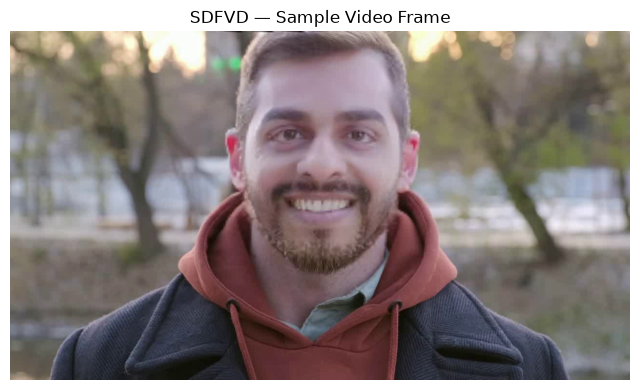

In [16]:
# ============================================================
# DISPLAY FIRST FRAME
# ============================================================

cap = cv2.VideoCapture(video_path)

success, frame = cap.read()

cap.release()

if success:

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(8, 5))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.title("SDFVD — Sample Video Frame")
    plt.show()

else:
    print("❌ Could not read first frame")

In [17]:
# ============================================================
# EXTRACT 16 FRAMES FROM SAMPLE VIDEO
# ============================================================

NUM_FRAMES = 16

cap = cv2.VideoCapture(video_path)

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

frame_indices = np.linspace(
    0,
    total_frames - 1,
    NUM_FRAMES,
    dtype=int
)

frames = []

for idx in frame_indices:

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))

    success, frame = cap.read()

    if success:
        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        frames.append(frame)

cap.release()

print("Total video frames :", total_frames)
print("Frames extracted   :", len(frames))
print("Expected frames    :", NUM_FRAMES)

Total video frames : 82
Frames extracted   : 16
Expected frames    : 16


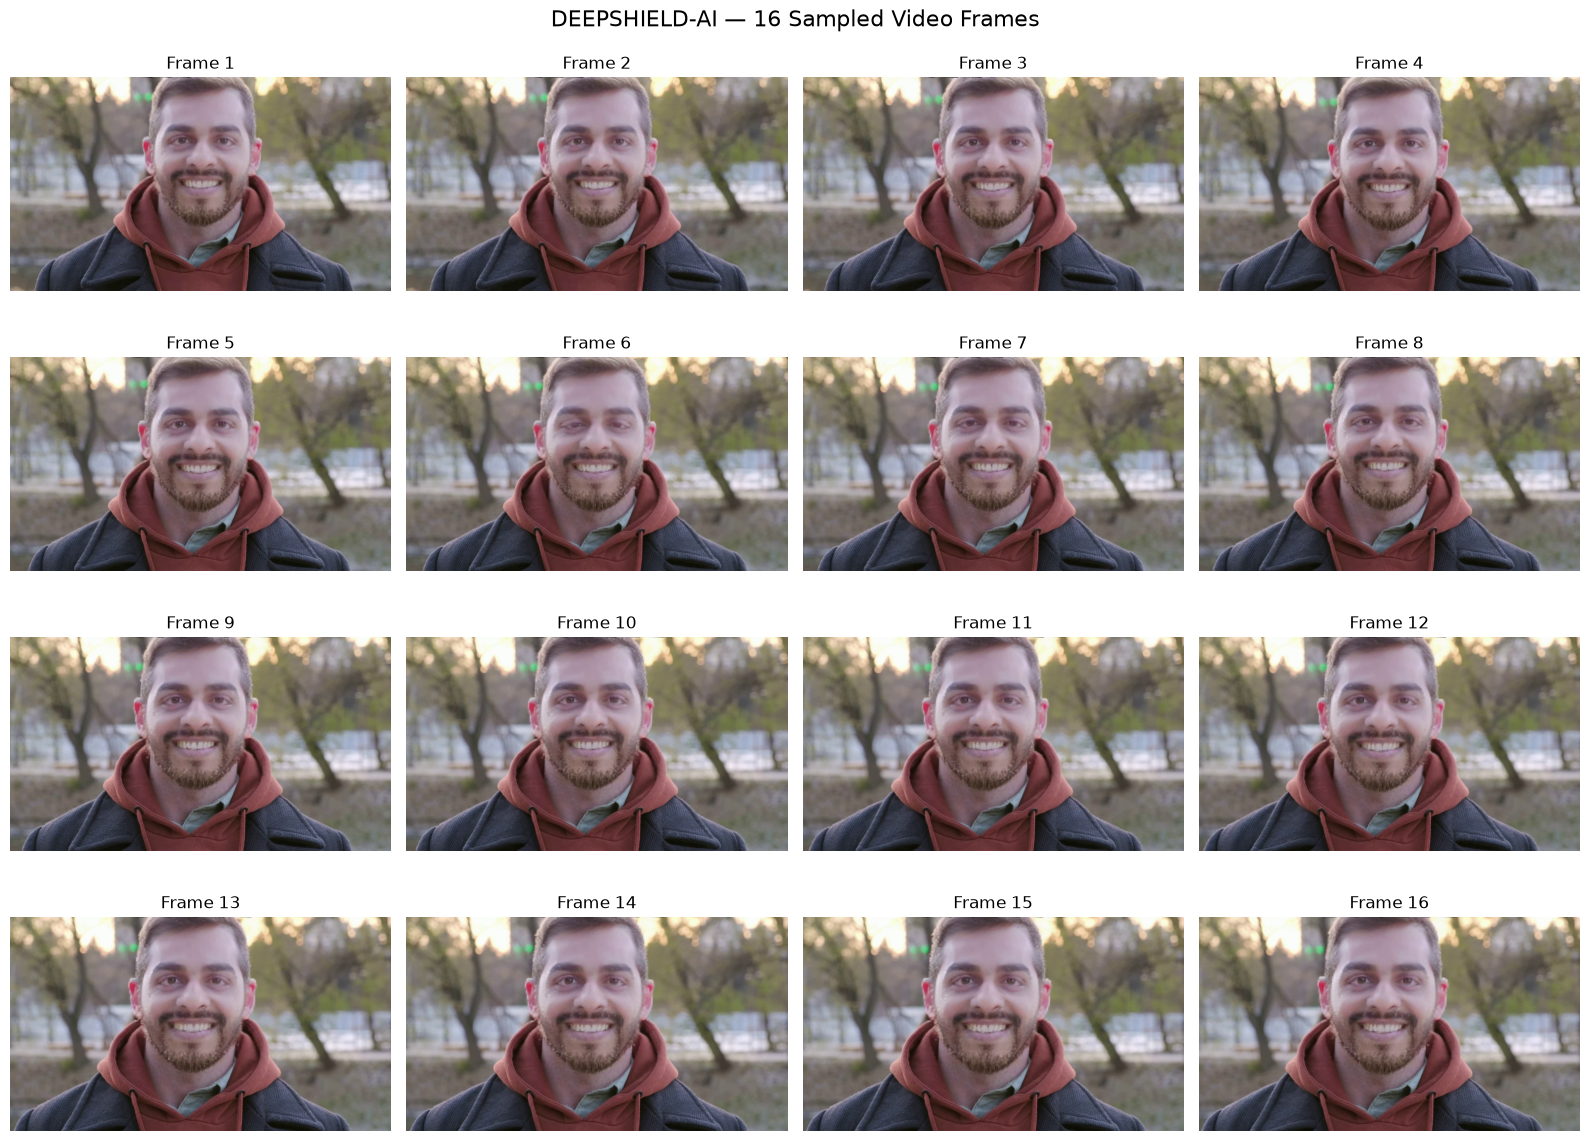

In [18]:
# ============================================================
# VISUALIZE EXTRACTED VIDEO FRAMES
# ============================================================

fig, axes = plt.subplots(
    4, 4,
    figsize=(16, 12)
)

for i, frame in enumerate(frames):

    ax = axes[i // 4, i % 4]

    ax.imshow(frame)
    ax.set_title(f"Frame {i + 1}")
    ax.axis("off")

plt.suptitle(
    "DEEPSHIELD-AI — 16 Sampled Video Frames",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# VIDEO FRAME PREPROCESSING
# ============================================================

from PIL import Image
from torchvision import transforms

FRAME_SIZE = 224

video_transform = transforms.Compose([
    transforms.Resize((FRAME_SIZE, FRAME_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

processed_frames = []

for frame in frames:

    # NumPy array → PIL Image
    image = Image.fromarray(frame)

    # Apply preprocessing
    tensor = video_transform(image)

    processed_frames.append(tensor)

# Convert list → single tensor
video_tensor = torch.stack(processed_frames)

print("Video preprocessing complete.")
print("Number of frames :", len(processed_frames))
print("Tensor shape     :", video_tensor.shape)
print("Data type        :", video_tensor.dtype)

Video preprocessing complete.
Number of frames : 16
Tensor shape     : torch.Size([16, 3, 224, 224])
Data type        : torch.float32


In [20]:
# ============================================================
# DEEPSHIELD-AI — VIDEO MODEL ARCHITECTURE
# ResNet18 + LSTM
# ============================================================

import torch
import torch.nn as nn
from torchvision import models


class VideoDeepShieldModel(nn.Module):

    def __init__(
        self,
        hidden_size=256,
        num_layers=2,
        num_classes=2
    ):

        super().__init__()

        # ----------------------------------------------------
        # FRAME FEATURE EXTRACTOR
        # ----------------------------------------------------

        self.cnn = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        # Remove final classification layer
        self.cnn.fc = nn.Identity()

        # ResNet18 feature size = 512
        feature_size = 512

        # ----------------------------------------------------
        # TEMPORAL MODEL
        # ----------------------------------------------------

        self.lstm = nn.LSTM(
            input_size=feature_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        # ----------------------------------------------------
        # FINAL CLASSIFIER
        # ----------------------------------------------------

        self.classifier = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        # x shape:
        # [batch, frames, channels, height, width]

        batch_size, num_frames, C, H, W = x.shape

        # ----------------------------------------------------
        # PROCESS EACH FRAME WITH CNN
        # ----------------------------------------------------

        x = x.view(
            batch_size * num_frames,
            C,
            H,
            W
        )

        features = self.cnn(x)

        # Shape:
        # [batch * frames, 512]

        features = features.view(
            batch_size,
            num_frames,
            -1
        )

        # Shape:
        # [batch, frames, 512]

        # ----------------------------------------------------
        # PROCESS TEMPORAL INFORMATION
        # ----------------------------------------------------

        lstm_output, _ = self.lstm(features)

        # Shape:
        # [batch, frames, hidden_size]

        # Use final frame's temporal representation
        final_features = lstm_output[:, -1, :]

        # ----------------------------------------------------
        # CLASSIFICATION
        # ----------------------------------------------------

        output = self.classifier(final_features)

        return output


print("Video model architecture created.")

Video model architecture created.


In [21]:
# ============================================================
# INITIALIZE VIDEO MODEL
# ============================================================

video_model = VideoDeepShieldModel(
    hidden_size=256,
    num_layers=2,
    num_classes=2
)

video_model = video_model.to(DEVICE)

print("=" * 60)
print("VIDEO MODEL")
print("=" * 60)

print("Model       : ResNet18 + LSTM")
print("CNN         : ResNet18")
print("CNN Features: 512")
print("LSTM Hidden : 256")
print("LSTM Layers : 2")
print("Classes     : 2")
print("Device      :", DEVICE)

VIDEO MODEL
Model       : ResNet18 + LSTM
CNN         : ResNet18
CNN Features: 512
LSTM Hidden : 256
LSTM Layers : 2
Classes     : 2
Device      : cuda


In [22]:
# ============================================================
# VIDEO MODEL FORWARD PASS TEST
# ============================================================

video_input = video_tensor.unsqueeze(0)

print("Input shape:", video_input.shape)

video_input = video_input.to(DEVICE)

with torch.no_grad():

    output = video_model(video_input)

print("Output shape:", output.shape)
print("Raw output  :", output)

Input shape: torch.Size([1, 16, 3, 224, 224])
Output shape: torch.Size([1, 2])
Raw output  : tensor([[0.0282, 0.0538]], device='cuda:0')


In [23]:
# ============================================================
# GPU MEMORY CHECK
# ============================================================

if torch.cuda.is_available():

    allocated = torch.cuda.memory_allocated() / (1024 ** 2)
    reserved = torch.cuda.memory_reserved() / (1024 ** 2)

    print("GPU Memory Allocated :", round(allocated, 2), "MB")
    print("GPU Memory Reserved  :", round(reserved, 2), "MB")

else:

    print("Running on CPU.")

GPU Memory Allocated : 65.58 MB
GPU Memory Reserved  : 168.0 MB
